### Establecer semilla

In [46]:
import torch
import random
import numpy as np
import os

def set_seed(seed=42):
    # 1. Fija la semilla para el módulo random base de Python
    random.seed(seed)
    
    # 2. Fija la semilla en las variables de entorno (afecta al hash de Python)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. Fija la semilla para NumPy (muy importante si usas Pandas o Scikit-learn)
    np.random.seed(seed)
    
    # 4. Fija la semilla para PyTorch (CPU)
    torch.manual_seed(seed)
    
    # 5. Fija la semilla para PyTorch (GPU / CUDA)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Si usas múltiples GPUs
    
    # 6. Fuerza a CuDNN a usar algoritmos deterministas (solo si usas GPU)
    # Se prioriza la reproducibilidad determinista durante la fase experimental mediante la restricción de heurísticas de cuDNN,
    # asumiendo una ligera penalización en el rendimiento computacional a favor del rigor evaluativo.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Ejecuta la función al inicio
set_seed(112)

### Carga de archivos .parquet y análisis de distribución de servicios

Se han encontrado 7 archivos Parquet.
¡Hecho! Dataset total con 1,916,757 registros cargados.

--- CLASES DETECTADAS (8) ---
Clase 0: Benigno -> 958,109 registros
Clase 1: Credential Access -> 871,188 registros
Clase 2: Defense Evasion -> 6,048 registros
Clase 3: Exfiltration -> 559 registros
Clase 4: Initial Access -> 10,662 registros
Clase 5: Persistence -> 6,048 registros
Clase 6: Privilege Escalation -> 6,048 registros
Clase 7: Reconnaissance -> 58,095 registros

--- DISTRIBUCIÓN GLOBAL ---
             Cantidad  Porcentaje (%)
service                              
dns            879490           45.88
ssl            860606           44.90
desconocido    154477            8.06
http             9847            0.51
ntp              6628            0.35


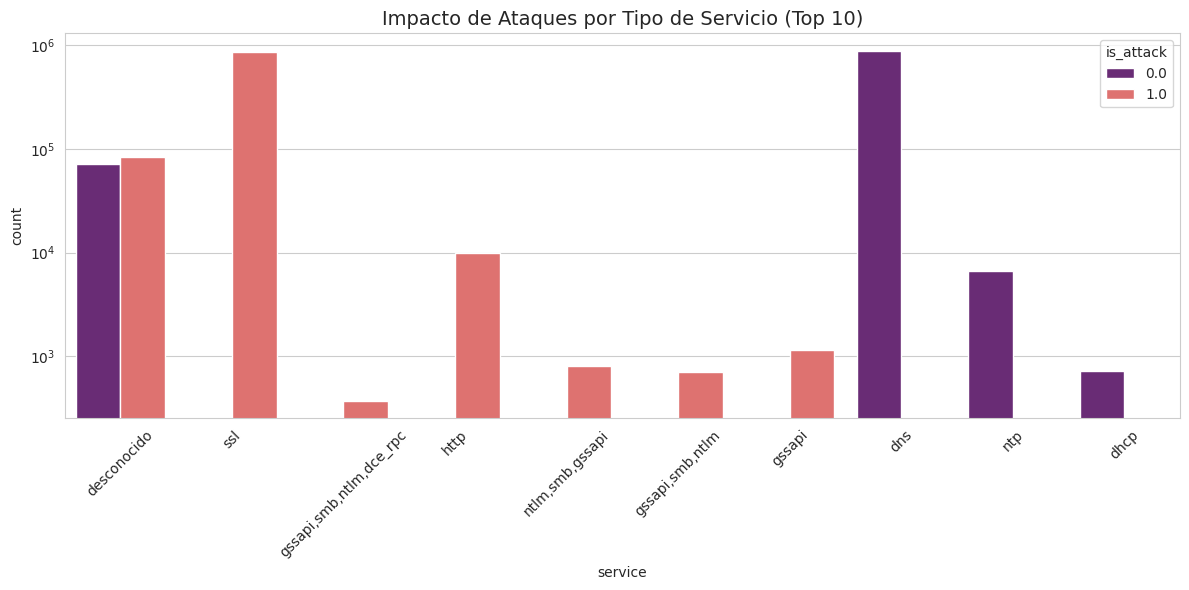

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. LOCALIZACIÓN Y CARGA
archivos_parquet = glob.glob("../data/raw/*.parquet")
print(f"Se han encontrado {len(archivos_parquet)} archivos Parquet.")

lista_df = []
for f in archivos_parquet:
    # Añadimos las columnas numéricas que Zeek nos da para las Edge Features
    columnas_interes = ['service', 'label_tactic', 'src_ip_zeek', 'dest_ip_zeek', 
                        'duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'conn_state', 'missed_bytes', 'ts']
    temp_df = pd.read_parquet(f, columns=columnas_interes)
    lista_df.append(temp_df)

df = pd.concat(lista_df, ignore_index=True)
print(f"¡Hecho! Dataset total con {len(df):,} registros cargados.")

# 2. LIMPIEZA Y CODIFICACIÓN DE ETIQUETAS MULTICLASE
df['service'] = df['service'].replace(['-', ''], 'desconocido').fillna('desconocido')
df['is_attack'] = (df['label_tactic'].fillna('none').str.lower() != 'none').astype(float)

# Limpiamos los nulos y asignamos 'Benigno' a lo que no es ataque
df['label_tactic'] = df['label_tactic'].fillna('Benigno').replace(['none', '-'], 'Benigno')

# Codificamos las tácticas a números (0, 1, 2...)
encoder_tactics = LabelEncoder()
df['target_class'] = encoder_tactics.fit_transform(df['label_tactic'])

num_clases = len(encoder_tactics.classes_)
print(f"\n--- CLASES DETECTADAS ({num_clases}) ---")
for i, clase in enumerate(encoder_tactics.classes_):
    print(f"Clase {i}: {clase} -> {len(df[df['target_class'] == i]):,} registros")

# 3. DIAGNÓSTICO
resumen = pd.DataFrame({
    'Cantidad': df['service'].value_counts(),
    'Porcentaje (%)': (df['service'].value_counts(normalize=True) * 100).round(2)
})
print("\n--- DISTRIBUCIÓN GLOBAL ---")
print(resumen.head())

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
top_10 = df['service'].value_counts().head(10).index
df_plot = df[df['service'].isin(top_10)]

sns.countplot(data=df_plot, x='service', hue='is_attack', palette='magma')
plt.title('Impacto de Ataques por Tipo de Servicio (Top 10)', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Feature Engineering (Nodos Inductivos y Aristas)

Para que el modelo sea verdaderamente inductivo y agnóstico a la IP, las características iniciales de los nodos (X) deben ser estadísticas de comportamiento.

In [48]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("1. Procesando Características de las Aristas (Edge Features Avanzadas)...")

# --- INGENIERÍA DE CARACTERÍSTICAS TEMPORALES ---
print("Calculando delta temporal para detectar Persistencia (Beaconing)...")
# Ordenamos por IP Origen, IP Destino y Timestamp (ts)
df = df.sort_values(by=['src_ip_zeek', 'dest_ip_zeek', 'ts'])
# Calculamos la diferencia de tiempo con la conexión inmediatamente anterior
df['time_since_last_conn'] = df.groupby(['src_ip_zeek', 'dest_ip_zeek'])['ts'].diff().fillna(0.0)

# 1. Añadimos variable temporal y missed_bytes
edge_cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'missed_bytes', 'time_since_last_conn']
df[edge_cols] = df[edge_cols].fillna(0)

# 2. One-Hot Encoding del estado de la conexión
df['conn_state'] = df['conn_state'].fillna('OTH')
conn_state_dummies = pd.get_dummies(df['conn_state'], prefix='state').astype(float)

# 3. Concatenamos numéricas y categóricas
edge_features_df = pd.concat([df[edge_cols], conn_state_dummies], axis=1)

# 4. Estandarizamos (vital porque la columna temporal puede tener valores muy dispares)
scaler_edges = StandardScaler()
edge_features_np = scaler_edges.fit_transform(edge_features_df.values)

print(f"-> Aristas procesadas. Nuevas dimensiones de Edge Features: {edge_features_np.shape[1]} columnas")
print("2. Procesando Características de los Nodos (Node Features Inductivas)...")
ips_unicas = pd.unique(df[['src_ip_zeek', 'dest_ip_zeek']].values.ravel('K'))

# USO DE NAMED AGGREGATION (Soluciona el error de las columnas)
# Calculamos estadísticas cuando la IP actúa como ORIGEN (Out)
out_stats = df.groupby('src_ip_zeek').agg(
    out_bytes_mean=('orig_bytes', 'mean'),
    out_pkts_mean=('orig_pkts', 'mean'),
    out_degree=('orig_bytes', 'count') # El conteo de conexiones
)

# Calculamos estadísticas cuando la IP actúa como DESTINO (In)
in_stats = df.groupby('dest_ip_zeek').agg(
    in_bytes_mean=('resp_bytes', 'mean'),
    in_pkts_mean=('resp_pkts', 'mean'),
    in_degree=('resp_bytes', 'count')
)

node_df = pd.DataFrame(index=ips_unicas)
node_df = node_df.join(out_stats).join(in_stats).fillna(0)

scaler_nodes = StandardScaler()
node_features_np = scaler_nodes.fit_transform(node_df.values)

print(f"-> Nodos procesados con éxito: {len(ips_unicas):,}")

1. Procesando Características de las Aristas (Edge Features Avanzadas)...
Calculando delta temporal para detectar Persistencia (Beaconing)...
-> Aristas procesadas. Nuevas dimensiones de Edge Features: 14 columnas
2. Procesando Características de los Nodos (Node Features Inductivas)...
-> Nodos procesados con éxito: 357


### Construcción del Grafo en PyTorch

In [49]:
import torch

print("Construyendo matriz de adyacencia...")
# Codificamos las IPs a índices numéricos (0 a N)
encoder = LabelEncoder()
encoder.fit(ips_unicas)
df['src_id'] = encoder.transform(df['src_ip_zeek'])
df['dst_id'] = encoder.transform(df['dest_ip_zeek'])

# 1. Matriz de Adyacencia Global (edge_index) [2, num_aristas]
origen = torch.tensor(df['src_id'].values, dtype=torch.long)
destino = torch.tensor(df['dst_id'].values, dtype=torch.long)
edge_index_total = torch.stack([origen, destino], dim=0)

# 2. Tensores de Características (X) y Aristas (Edge_Attr)
x_nodos = torch.tensor(node_features_np, dtype=torch.float)
edge_attr_total = torch.tensor(edge_features_np, dtype=torch.float)

# 3. Etiquetas (Target multiclase)
# IMPORTANTE: CrossEntropyLoss requiere que las etiquetas sean 'long' (enteros)
y_total = torch.tensor(df['target_class'].values, dtype=torch.long)
edge_services = df['service'].values

print(f"Tensor X (Nodos): {x_nodos.shape}")
print(f"Tensor edge_index (Topología): {edge_index_total.shape}")

Construyendo matriz de adyacencia...
Tensor X (Nodos): torch.Size([357, 6])
Tensor edge_index (Topología): torch.Size([2, 1916757])


### Enrutador y Partición Estratificada Train/Test

In [50]:
from sklearn.model_selection import train_test_split
import numpy as np
import torch

print("Generando divisiones estratificadas: Train (70%), Val (10%), Test (20%)...")

# 1. Estratificación
df['stratify_key'] = df['service'] + '_' + df['is_attack'].astype(int).astype(str)
conteo_clases = df['stratify_key'].value_counts()
clases_validas = conteo_clases[conteo_clases > 1].index

indices_validos = df.index[df['stratify_key'].isin(clases_validas)].tolist()

# --- DOBLE DIVISIÓN (Train/Val/Test) ---
# Primera división: separamos el 20% para Test
idx_train_val, idx_test = train_test_split(
    indices_validos, 
    test_size=0.20, 
    random_state=42, 
    stratify=df.loc[indices_validos, 'stratify_key']
)

# Segunda división: del 80% restante, sacamos un 12.5% (que equivale exactamente al 10% del total global) para Val
idx_train, idx_val = train_test_split(
    idx_train_val, 
    test_size=0.125, 
    random_state=42, 
    stratify=df.loc[idx_train_val, 'stratify_key']
)

# Inicializamos las máscaras maestras
train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[idx_train] = True
val_mask[idx_val] = True
test_mask[idx_test] = True

# 2. DEFINIMOS LOS GRUPOS LÓGICOS DE SERVICIOS
servicios = df['service'].values
is_ataque = df['is_attack'].values
is_ataque_tensor = torch.tensor(is_ataque == 1, dtype=torch.bool)

mask_web = np.isin(servicios, ['ssl', 'http'])
mask_infra = np.isin(servicios, ['dns', 'ntp', 'dhcp'])
mask_auth = np.isin(servicios, ['smb', 'gssapi', 'ntlm', 'dce_rpc', 'gssapi,smb,ntlm', 'smb,dce_rpc,ntlm,gssapi', 'ntlm,dce_rpc,smb,gssapi']) 
mask_gen = ~(mask_web | mask_infra | mask_auth) 

# --- INYECCIÓN DE VARIANZA (SOLO PARA TRAIN) ---
benignos_disponibles = mask_gen & (is_ataque == 0)
ataques_disponibles = mask_gen & (is_ataque == 1)

mask_train_web = (mask_web | benignos_disponibles)
mask_train_infra = (mask_infra | ataques_disponibles)
mask_train_auth = (mask_auth | benignos_disponibles) 

# ========================================================
# MÁSCARAS FASE 1: BINARIAS (Portero)
# ========================================================
# TRAIN (Con Inyección)
train_mask_web = torch.tensor(mask_train_web, dtype=torch.bool) & train_mask
train_mask_infra = torch.tensor(mask_train_infra, dtype=torch.bool) & train_mask
train_mask_auth = torch.tensor(mask_train_auth, dtype=torch.bool) & train_mask
train_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & train_mask

# VALIDACIÓN (Estrictas, reflejan la realidad para el Early Stopping)
val_mask_web = torch.tensor(mask_web, dtype=torch.bool) & val_mask
val_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & val_mask
val_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & val_mask
val_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & val_mask

# TEST (Estrictas)
test_mask_web = torch.tensor(mask_web, dtype=torch.bool) & test_mask
test_mask_infra = torch.tensor(mask_infra, dtype=torch.bool) & test_mask
test_mask_auth = torch.tensor(mask_auth, dtype=torch.bool) & test_mask
test_mask_gen = torch.tensor(mask_gen, dtype=torch.bool) & test_mask

# ========================================================
# MÁSCARAS FASE 2: MULTICLASE (Analista Forense)
# ========================================================
# TRAIN (Con Inyección de ataques cruzados)
ataques_inyeccion = torch.tensor(ataques_disponibles, dtype=torch.bool) & train_mask
train_mask_web_ataques = (test_mask_web & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_infra_ataques = (test_mask_infra & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_auth_ataques = (test_mask_auth & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_gen_ataques = train_mask_gen & is_ataque_tensor

# VALIDACIÓN (Solo evalúan sobre ataques reales y naturales del set de Val)
val_mask_web_ataques = val_mask_web & is_ataque_tensor
val_mask_infra_ataques = val_mask_infra & is_ataque_tensor
val_mask_auth_ataques = val_mask_auth & is_ataque_tensor
val_mask_gen_ataques = val_mask_gen & is_ataque_tensor


# --- UNDERSAMPLING SELECTIVO Y BLINDADO ---
# 1. Definimos qué clases son sagradas y NO deben tocarse nunca
clases_sagradas = ['Exfiltration', 'Persistence', 'Defense Evasion', 'Privilege Escalation']
ids_sagrados = encoder_tactics.transform(clases_sagradas)

# 2. Identificamos los índices que son candidatos a ser borrados:
# Solo borraremos si es 'Benigno' o 'Credential Access' (id 0 e id 1 normalmente)
# Y SOLO si están en el conjunto de entrenamiento
idx_train_np = np.where(train_mask.numpy())[0]
y_train_cpu = y_total[idx_train_np].cpu().numpy()

# Buscamos quiénes NO son sagrados dentro del entrenamiento
idx_candidatos_borrado = []
for i, etiqueta in zip(idx_train_np, y_train_cpu):
    if etiqueta not in ids_sagrados:
        idx_candidatos_borrado.append(i)

# 3. Aplicamos el recorte solo a los candidatos (75% de descarte)
num_descarte = int(len(idx_candidatos_borrado) * 0.75)
np.random.seed(42)
idx_a_apagar = np.random.choice(idx_candidatos_borrado, num_descarte, replace=False)

# 4. Actualizamos la máscara de entrenamiento final
# Creamos una copia de la máscara original y apagamos los elegidos
mascara_apagado = torch.zeros(len(df), dtype=torch.bool)
mascara_apagado[idx_a_apagar] = True

train_mask_web = train_mask_web & ~mascara_apagado
train_mask_infra = train_mask_infra & ~mascara_apagado
train_mask_auth = train_mask_auth & ~mascara_apagado
train_mask_gen = train_mask_gen & ~mascara_apagado

print(f"Undersampling completado. Se han protegido las clases: {clases_sagradas}")

Generando divisiones estratificadas: Train (70%), Val (10%), Test (20%)...
Undersampling completado. Se han protegido las clases: ['Exfiltration', 'Persistence', 'Defense Evasion', 'Privilege Escalation']


### Exportación de datos

In [51]:
import os
import json

print("\n--- Exportando Datasets de Simulación e Histórico ---")
os.makedirs("../data/processed", exist_ok=True)

# 1. El Dataset de Simulación (SOLO TEST)
df_test_estricto = df.iloc[idx_test].copy()
df_test_estricto = df_test_estricto.sort_values(by='ts')
df_test_estricto.to_parquet("../data/processed/dataset_simulacion_kafka.parquet", index=False)

# 2. El Dataset Histórico para Neo4j (TRAIN + VAL)
df_historico = df[~df.index.isin(idx_test)].copy()
df_historico = df_historico.sort_values(by='ts')
df_historico.to_parquet("../data/processed/dataset_historico_neo4j.parquet", index=False)

# 3. Exportar el orden de las columnas (esto no cambia)
columnas_modelo = list(edge_features_df.columns)
with open("../data/processed/columnas_modelo.json", "w") as f:
    json.dump(columnas_modelo, f)

print(f"✅ Simulación (Test) exportada: {len(df_test_estricto):,} registros.")
print(f"✅ Histórico (Train+Val) exportado: {len(df_historico):,} registros.")


--- Exportando Datasets de Simulación e Histórico ---
✅ Simulación (Test) exportada: 383,352 registros.
✅ Histórico (Train+Val) exportado: 1,533,405 registros.


### Arquitectura GraphSAGE (El Modelo)

In [52]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, GATConv

class AdvancedEdgeExpert(torch.nn.Module):
    def __init__(self, node_in_channels, edge_in_channels, hidden_channels, out_classes, conv_type='SAGE', dropout_rate=0.3):
        super(AdvancedEdgeExpert, self).__init__()
        self.conv_type = conv_type
        
        # --- DIVERSIDAD ARQUITECTÓNICA ---
        if conv_type == 'SAGE':
            self.conv1 = SAGEConv(node_in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
            self.conv3 = SAGEConv(hidden_channels, hidden_channels) # NUEVA CAPA
        elif conv_type == 'GAT':
            # GAT usa cabezales de atención (heads). Multiplican la salida, 
            # así que dividimos los canales para mantener la dimensión final igual.
            heads = 4
            self.conv1 = GATConv(node_in_channels, hidden_channels // heads, heads=heads)
            self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads) # AHORA MANTIENE HEADS
            self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1) # NUEVA CAPA FINAL

        
        # --- PERCEPTRÓN DINÁMICO ---
        clf_input_dim = (hidden_channels * 2) + edge_in_channels
        self.edge_classifier = nn.Sequential(
            nn.Linear(clf_input_dim, hidden_channels),
            nn.BatchNorm1d(hidden_channels), # Batch Normalization ayuda mucho a la convergencia
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, out_classes) 
        )

    def forward(self, x, edge_index_msg, edge_index_pred, edge_attr_pred):
        x = self.conv1(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv2(x, edge_index_msg)
        x = F.relu(x)
        x = self.conv3(x, edge_index_msg)
        
        src = edge_index_pred[0]
        dst = edge_index_pred[1]
        
        edge_features = torch.cat([x[src], x[dst], edge_attr_pred], dim=-1)
        
        return self.edge_classifier(edge_features)


# Mejoras integradas para robustez y generalización

Cambios aplicados directamente al pipeline:

- Gamma dinámico para Focal Loss
- Oversampling basado en percentiles
- Corrección automática de device CUDA/CPU
- Early stopping usando Macro-F1
- Eliminación de parada por "perfección"
- Mitigación de leakage topológico
- Normalización más estable de pesos de clases

Las funciones auxiliares se definen justo antes de utilizarse
para mantener el notebook legible y autocontenido.


### Bucle de Entrenamiento

Consideraciones sobre el Data Leakage Topológico: En el paradigma transductivo de aprendizaje sobre grafos utilizado (donde la estructura completa es observable pero las etiquetas de validación/test están enmascaradas), existe un riesgo teórico inherente de filtración estructural durante la agregación de vecindarios (Message Passing). Aunque la pérdida (Focal Loss) y la retropropagación se restringen estrictamente a la máscara de entrenamiento, las incrustaciones (embeddings) resultantes pueden absorber información latente de la conectividad de prueba. Para futuros despliegues puramente inductivos en streaming, se recomienda el uso de mini-batching topológico estricto o extracción de subgrafos dinámicos.

In [53]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}\n")

# --- 1. ETIQUETAS Y MÁSCARAS DE DOS FASES ---
y_binario = torch.tensor(df['is_attack'].astype(int).values, dtype=torch.long).to(device)
is_ataque_tensor = torch.tensor(df['is_attack'].values == 1, dtype=torch.bool)

# Para la Fase 2 (Multiclase) aislamos los ataques. 
# Inyectamos ataques variados a todos los expertos para que puedan comparar tácticas internamente
ataques_inyeccion = torch.tensor(ataques_disponibles, dtype=torch.bool) & train_mask

train_mask_web_ataques = (torch.tensor(mask_web, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_infra_ataques = (torch.tensor(mask_infra, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_auth_ataques = (torch.tensor(mask_auth, dtype=torch.bool) & train_mask & is_ataque_tensor) | ataques_inyeccion
train_mask_gen_ataques = torch.tensor(mask_gen, dtype=torch.bool) & train_mask & is_ataque_tensor


# --- 2. COMITÉ FASE 1: BINARIO (El Filtro Portero) ---
# Predicen 2 clases (out_classes=2): 0 o 1
model_bin_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'SAGE', 0.3).to(device)
model_bin_infra = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, 2, 'SAGE', 0.2).to(device)
model_bin_auth = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, 2, 'GAT', 0.4).to(device)
model_bin_gen = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, 2, 'GAT', 0.5).to(device)

opt_bin_web = torch.optim.Adam(model_bin_web.parameters(), lr=0.005)
opt_bin_infra = torch.optim.Adam(model_bin_infra.parameters(), lr=0.005)
opt_bin_auth = torch.optim.Adam(model_bin_auth.parameters(), lr=0.003)
opt_bin_gen = torch.optim.Adam(model_bin_gen.parameters(), lr=0.001)

# --- 3. COMITÉ FASE 2: MULTICLASE (El Analista Forense - Soft Voting Ensemble) ---
# WEB: Se queda en SAGE (Topología sencilla)
model_multi_web = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.3).to(device)
opt_multi_web = torch.optim.Adam(model_multi_web.parameters(), lr=0.005)

# INFRA: SAGE + GAT
model_multi_infra_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'SAGE', 0.2).to(device)
model_multi_infra_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 64, num_clases, 'GAT', 0.2).to(device)
opt_multi_infra_sage = torch.optim.Adam(model_multi_infra_sage.parameters(), lr=0.005)
opt_multi_infra_gat = torch.optim.Adam(model_multi_infra_gat.parameters(), lr=0.001)

# AUTH: SAGE + GAT
model_multi_auth_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'SAGE', 0.4).to(device)
model_multi_auth_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 128, num_clases, 'GAT', 0.4).to(device)
opt_multi_auth_sage = torch.optim.Adam(model_multi_auth_sage.parameters(), lr=0.003)
opt_multi_auth_gat = torch.optim.Adam(model_multi_auth_gat.parameters(), lr=0.001)

# GENERALISTA: SAGE + GAT
model_multi_gen_sage = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'SAGE', 0.5).to(device)
model_multi_gen_gat = AdvancedEdgeExpert(x_nodos.shape[1], edge_attr_total.shape[1], 256, num_clases, 'GAT', 0.5).to(device)
opt_multi_gen_sage = torch.optim.Adam(model_multi_gen_sage.parameters(), lr=0.001)
opt_multi_gen_gat = torch.optim.Adam(model_multi_gen_gat.parameters(), lr=0.001)

# Movemos los datos globales a la memoria de la GPU
x_nodos = x_nodos.to(device)
edge_index_total = edge_index_total.to(device)

def gestionar_mascaras_y_fallback(mascara_train, mascara_val):
    """
    Extrae los índices de entrenamiento y validación. 
    Aplica un fallback 80/20 si la máscara de validación queda vacía por azar.
    """
    idx_train = torch.where(mascara_train)[0].cpu()
    idx_val = torch.where(mascara_val)[0].cpu()
    
    if len(idx_val) == 0 and len(idx_train) > 0:
        print("⚠️ Validación vacía. Aplicando split 80/20 interno de seguridad.")
        perm = torch.randperm(len(idx_train))
        split = int(len(idx_train) * 0.8)
        idx_val = idx_train[perm[split:]]
        idx_train = idx_train[perm[:split]]
        
    return idx_train, idx_val

def aplicar_augmentacion_topologica(idx_train_base, y_target, is_multiclass, num_clases):
    """
    Clona los índices de las aristas de clases minoritarias (Percentil 25) 
    para aumentar su representatividad estructural en la GNN.
    """
    if not is_multiclass:
        return idx_train_base
        
    y_train_np = y_target[idx_train_base].cpu().numpy()
    counts = np.bincount(y_train_np, minlength=num_clases)
    counts_validos = counts[counts > 0]
    
    umbral_minoria = np.percentile(counts_validos, 25) 
    indices_extra = []
    
    for c in np.unique(y_train_np):
        if 0 < counts[c] <= umbral_minoria:
            factor = int(umbral_minoria / counts[c])
            if factor > 1:
                indices_clase = idx_train_base[y_train_np == c]
                indices_extra.extend(np.tile(indices_clase.numpy(), factor - 1))
    
    if indices_extra:
        print(f"[*] Augmentación: +{len(indices_extra)} aristas (Percentil 25: {umbral_minoria:.0f}).")
        return torch.cat([idx_train_base, torch.tensor(indices_extra, dtype=torch.long)])
        
    return idx_train_base

def calcular_focal_loss_dinamica(y_train, is_multiclass, num_clases, device):
    """
    Calcula los pesos usando Effective Number of Samples (Cui et al.) y 
    un Gamma dinámico basado en el ratio de desbalanceo local.
    """
    conteo = np.bincount(y_train.cpu().numpy(), minlength=num_clases if is_multiclass else 2)
    beta = 0.9999
    pesos = torch.ones(len(conteo), device=device)
    gammas = torch.full((len(conteo),), 2.0, device=device) 

    for c in range(len(conteo)):
        if conteo[c] > 0:
            eff_num = (1.0 - np.power(beta, conteo[c])) / (1.0 - beta)
            pesos[c] = 1.0 / eff_num
            if is_multiclass:
                ratio = np.max(conteo[conteo > 0]) / conteo[c]
                gammas[c] = min(3.0, 1.0 + np.log10(ratio)) 

    # Normalización para no inflar artificialmente el learning rate
    clases_presentes = len(np.unique(y_train.cpu().numpy()))
    pesos = (pesos / pesos.sum()) * clases_presentes
    
    return FocalLoss(weight=pesos, gamma=gammas.mean().item())

# --- 1. DEFINICIÓN DE FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma # Gamma controla cuánto se ignoran los ejemplos fáciles (2.0 es el estándar de la industria)

    def forward(self, inputs, targets):
        # Calculamos la CrossEntropy normal sin reducción
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        # pt es la probabilidad que el modelo le dio a la clase correcta
        pt = torch.exp(-ce_loss)
        # Aplicamos el factor focal: (1 - probabilidad)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

def entrenar_experto_gnn(nombre, modelo, optimizador, mascara_train, mascara_val, y_target, grafo_global, is_multiclass=False, epochs=1000, paciencia=50):
    """
    Motor principal de entrenamiento. Delega la preparación de datos y matemáticas
    en funciones auxiliares para mantener el Principio de Responsabilidad Única.
    """
    print(f"\n--- Entrenando Experto: {nombre} ---")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    modelo.to(device)

    # Desempaquetar datos del grafo global (Evita variables hardcodeadas)
    x_nodos = grafo_global['x_nodos'].to(device)
    edge_index_t = grafo_global['edge_index_total']
    edge_attr_t = grafo_global['edge_attr_total']
    num_clases = grafo_global['num_clases']

    # 1. Preparación de Índices
    idx_train_base, idx_val = gestionar_mascaras_y_fallback(mascara_train, mascara_val)
    if len(idx_train_base) == 0:
        print(f"❌ Error: Sin datos de entrenamiento para {nombre}")
        return

    # 2. Augmentación Topológica
    idx_train_final = aplicar_augmentacion_topologica(idx_train_base, y_target, is_multiclass, num_clases)

    # 3. Construcción segura de Tensores (.to(device) Bulletproof)
    edge_idx_train = edge_index_t[:, idx_train_final.to(edge_index_t.device)].to(device)
    edge_attr_train = edge_attr_t[idx_train_final.to(edge_attr_t.device)].to(device)
    y_train = y_target[idx_train_final.to(y_target.device)].to(device)
    
    edge_idx_val = edge_index_t[:, idx_val.to(edge_index_t.device)].to(device)
    edge_attr_val = edge_attr_t[idx_val.to(edge_attr_t.device)].to(device)
    y_val = y_target[idx_val.to(y_target.device)].to(device)

    # 4. Obtener Función de Pérdida Dinámica
    criterion = calcular_focal_loss_dinamica(y_train, is_multiclass, num_clases, device)

    # 5. Bucle de Entrenamiento
    mejor_f1_val = -1.0 
    mejor_modelo_pesos = None
    paciencia_cnt = 0

    for epoch in range(epochs):
        # --- TRAIN ---
        modelo.train()
        optimizador.zero_grad()
        out = modelo(x_nodos, edge_index_t.to(device), edge_idx_train, edge_attr_train)
        loss = criterion(out, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        optimizador.step()

        # --- VALIDATION ---
        modelo.eval()
        with torch.no_grad():
            out_v = modelo(x_nodos, edge_index_t.to(device), edge_idx_val, edge_attr_val)
            preds_v = out_v.argmax(dim=1)
            f1_v = f1_score(y_val.cpu(), preds_v.cpu(), average='macro' if is_multiclass else 'binary', zero_division=0)

        # --- EARLY STOPPING ---
        if f1_v > mejor_f1_val:
            mejor_f1_val = f1_v
            mejor_modelo_pesos = copy.deepcopy(modelo.state_dict())
            paciencia_cnt = 0
        else:
            paciencia_cnt += 1

        if (epoch+1) % 50 == 0:
            print(f"Ep {epoch+1:03d} | Train Loss: {loss.item():.4f} | Val Macro-F1: {f1_v:.4f}")

        if paciencia_cnt >= paciencia:
            print(f"🛑 Early Stopping en ep {epoch+1}. Mejor Macro-F1: {mejor_f1_val:.4f}")
            break

    # Restaurar y finalizar
    if mejor_modelo_pesos is not None:
        modelo.load_state_dict(mejor_modelo_pesos)
    print(f"✅ Experto {nombre} listo.")
    
# ================= ENTRENAMIENTO EN MASA =================

# Definimos el entorno global del grafo para pasarlo a los expertos (Asegurando consistencia)
grafo_global = {
    'x_nodos': x_nodos,
    'edge_index_total': edge_index_total,
    'edge_attr_total': edge_attr_total,
    'num_clases': num_clases
}

print(">>> INICIANDO FASE 1 (MODELOS BINARIOS - FILTRADO)")
# Fase 1: Entrenamiento de porteros binarios para cada dominio
entrenar_experto_gnn("BIN. WEB", model_bin_web, opt_bin_web, train_mask_web, val_mask_web, y_binario, grafo_global, is_multiclass=False, epochs=150)
entrenar_experto_gnn("BIN. INFRA", model_bin_infra, opt_bin_infra, train_mask_infra, val_mask_infra, y_binario, grafo_global, is_multiclass=False, epochs=150)
entrenar_experto_gnn("BIN. AUTH", model_bin_auth, opt_bin_auth, train_mask_auth, val_mask_auth, y_binario, grafo_global, is_multiclass=False, epochs=200)
entrenar_experto_gnn("BIN. GEN", model_bin_gen, opt_bin_gen, train_mask_gen, val_mask_gen, y_binario, grafo_global, is_multiclass=False, epochs=250)

print("\n>>> INICIANDO FASE 2 (MODELOS MULTICLASE - CLASIFICACIÓN MITRE)")
# Fase 2: Entrenamiento de analistas multiclase con arquitecturas híbridas SAGE/GAT
entrenar_experto_gnn("MULTI WEB (SAGE)", model_multi_web, opt_multi_web, train_mask_web_ataques, val_mask_web_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

entrenar_experto_gnn("MULTI INFRA (GAT)", model_multi_infra_gat, opt_multi_infra_gat, train_mask_infra_ataques, val_mask_infra_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI INFRA (SAGE)", model_multi_infra_sage, opt_multi_infra_sage, train_mask_infra_ataques, val_mask_infra_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

entrenar_experto_gnn("MULTI AUTH (SAGE)", model_multi_auth_sage, opt_multi_auth_sage, train_mask_auth_ataques, val_mask_auth_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI AUTH (GAT)", model_multi_auth_gat, opt_multi_auth_gat, train_mask_auth_ataques, val_mask_auth_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000, paciencia=100)

entrenar_experto_gnn("MULTI GEN (SAGE)", model_multi_gen_sage, opt_multi_gen_sage, train_mask_gen_ataques, val_mask_gen_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)
entrenar_experto_gnn("MULTI GEN (GAT)", model_multi_gen_gat, opt_multi_gen_gat, train_mask_gen_ataques, val_mask_gen_ataques, y_total, grafo_global, is_multiclass=True, epochs=1000)

Entrenando en: cuda

>>> INICIANDO FASE 1 (MODELOS BINARIOS - FILTRADO)

--- Entrenando Experto: BIN. WEB ---
Ep 050 | Train Loss: 0.0000 | Val Macro-F1: 1.0000
🛑 Early Stopping en ep 51. Mejor Macro-F1: 1.0000
✅ Experto BIN. WEB listo.

--- Entrenando Experto: BIN. INFRA ---
Ep 050 | Train Loss: 0.0040 | Val Macro-F1: 0.0000
🛑 Early Stopping en ep 51. Mejor Macro-F1: 0.0000
✅ Experto BIN. INFRA listo.

--- Entrenando Experto: BIN. AUTH ---
Ep 050 | Train Loss: 0.0000 | Val Macro-F1: 1.0000
🛑 Early Stopping en ep 51. Mejor Macro-F1: 1.0000
✅ Experto BIN. AUTH listo.

--- Entrenando Experto: BIN. GEN ---
Ep 050 | Train Loss: 0.0199 | Val Macro-F1: 0.9840
Ep 100 | Train Loss: 0.0157 | Val Macro-F1: 0.9868
Ep 150 | Train Loss: 0.0129 | Val Macro-F1: 0.9874
Ep 200 | Train Loss: 0.0195 | Val Macro-F1: 0.9862
🛑 Early Stopping en ep 217. Mejor Macro-F1: 0.9882
✅ Experto BIN. GEN listo.

>>> INICIANDO FASE 2 (MODELOS MULTICLASE - CLASIFICACIÓN MITRE)

--- Entrenando Experto: MULTI WEB (SAGE) -

### Evaluación en el Conjunto de Test

Ejecutando Inferencia en Cascada con Soft Voting...

--- REPORTE DE EVALUACIÓN (CASCADA + SOFT VOTING ENSEMBLE) ---
                      precision    recall  f1-score   support

             Benigno       1.00      1.00      1.00    191573
   Credential Access       1.00      1.00      1.00    174400
     Defense Evasion       0.09      0.38      0.15      1200
        Exfiltration       0.06      0.77      0.11       115
      Initial Access       0.12      0.00      0.01      2157
         Persistence       0.16      0.17      0.17      1193
Privilege Escalation       0.12      0.39      0.18      1222
      Reconnaissance       0.90      0.42      0.57     11492

            accuracy                           0.97    383352
           macro avg       0.43      0.52      0.40    383352
        weighted avg       0.98      0.97      0.97    383352


🎯 Macro-F1 Global: 0.3967


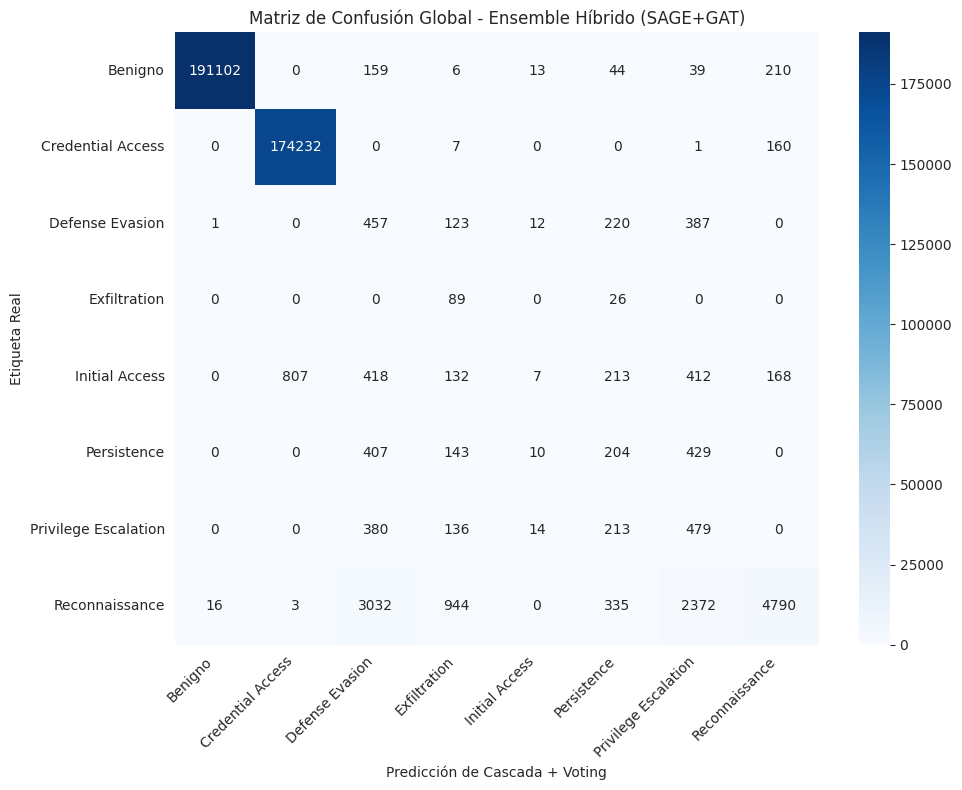

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import torch.nn.functional as F

print("Ejecutando Inferencia en Cascada con Soft Voting...")

todas_las_predicciones = []
todas_las_etiquetas = []
id_benigno = encoder_tactics.transform(['Benigno'])[0]

def predecir_cascada_voting(mascara_test, model_bin, lista_modelos_multi):
    if mascara_test.sum() == 0: return
    
    edge_index_test = edge_index_total[:, mascara_test]
    edge_attr_test = edge_attr_total[mascara_test].to(device)
    y_test_real = y_total[mascara_test].to(device)
    
    # 1. Fase Binaria (El Portero)
    model_bin.eval()
    with torch.no_grad():
        out_bin = model_bin(x_nodos, edge_index_total, edge_index_test, edge_attr_test)
        preds_bin = torch.argmax(out_bin, dim=1)
        
    # 2. Fase Multiclase (El Analista - Soft Voting)
    preds_finales = torch.full_like(preds_bin, fill_value=id_benigno)
    idx_ataques = torch.where(preds_bin == 1)[0]
    
    if len(idx_ataques) > 0:
        edge_index_ataques = edge_index_test[:, idx_ataques]
        edge_attr_ataques = edge_attr_test[idx_ataques]
        
        # Tensor para acumular las probabilidades de todos los modelos
        probabilidades_acumuladas = torch.zeros((len(idx_ataques), num_clases)).to(device)
        
        for mod in lista_modelos_multi:
            mod.eval()
            with torch.no_grad():
                out_multi = mod(x_nodos, edge_index_total, edge_index_ataques, edge_attr_ataques)
                # Convertimos logits a probabilidades antes de sumar
                probs = F.softmax(out_multi, dim=1) 
                probabilidades_acumuladas += probs
                
        # Promediamos las probabilidades
        probabilidades_finales = probabilidades_acumuladas / len(lista_modelos_multi)
        
        # IMPEDIMOS MATEMÁTICAMENTE que la fase 2 prediga 'Benigno'
        # Ponemos su probabilidad a 0.0 para que el argmax no lo elija
        probabilidades_finales[:, id_benigno] = 0.0 
        
        preds_multi = torch.argmax(probabilidades_finales, dim=1)
        preds_finales[idx_ataques] = preds_multi
        
    todas_las_predicciones.extend(preds_finales.cpu().numpy())
    todas_las_etiquetas.extend(y_test_real.cpu().numpy())

# Ejecutamos las 4 ramas del enrutador pasando las LISTAS de modelos
predecir_cascada_voting(test_mask_web, model_bin_web, [model_multi_web])
predecir_cascada_voting(test_mask_infra, model_bin_infra, [model_multi_infra_sage, model_multi_infra_gat])
predecir_cascada_voting(test_mask_auth, model_bin_auth, [model_multi_auth_sage, model_multi_auth_gat])
predecir_cascada_voting(test_mask_gen, model_bin_gen, [model_multi_gen_sage, model_multi_gen_gat])

y_true_global = np.array(todas_las_etiquetas)
preds_global = np.array(todas_las_predicciones)

print("\n--- REPORTE DE EVALUACIÓN (CASCADA + SOFT VOTING ENSEMBLE) ---")
clases_presentes = np.unique(np.concatenate((y_true_global, preds_global)))
nombres_clases = encoder_tactics.inverse_transform(clases_presentes)
nombres_clases_list = [str(c) for c in nombres_clases]

print(classification_report(y_true_global, preds_global, labels=clases_presentes, target_names=nombres_clases_list))

f1_macro = f1_score(y_true_global, preds_global, average='macro')
print(f"\n🎯 Macro-F1 Global: {f1_macro:.4f}")

cm = confusion_matrix(y_true_global, preds_global, labels=clases_presentes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases_list, yticklabels=nombres_clases_list)
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción de Cascada + Voting')
plt.title('Matriz de Confusión Global - Ensemble Híbrido (SAGE+GAT)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exportar modelos (con pesos y codificadores)

In [55]:
import joblib
import os
import torch

print("Guardando el Clasificador Jerárquico Híbrido para Producción...")
os.makedirs("modelos_produccion", exist_ok=True)

# 1. Guardamos Modelos FASE 1 (Binarios)
torch.save(model_bin_web.state_dict(), "../models/bin_web.pth")
torch.save(model_bin_infra.state_dict(), "../models/bin_infra.pth")
torch.save(model_bin_auth.state_dict(), "../models/bin_auth.pth")
torch.save(model_bin_gen.state_dict(), "../models/bin_gen.pth")

# 2. Guardamos Modelos FASE 2 (Multiclase)
torch.save(model_multi_web.state_dict(), "../models/multi_web_sage.pth")
torch.save(model_multi_infra_sage.state_dict(), "../models/multi_infra_sage.pth")
torch.save(model_multi_infra_gat.state_dict(), "../models/multi_infra_gat.pth")
torch.save(model_multi_auth_sage.state_dict(), "../models/multi_auth_sage.pth")
torch.save(model_multi_auth_gat.state_dict(), "../models/multi_auth_gat.pth")
torch.save(model_multi_gen_sage.state_dict(), "../models/multi_gen_sage.pth")
torch.save(model_multi_gen_gat.state_dict(), "../models/multi_gen_gat.pth")

# 3. Guardamos los Scalers y Encoders
joblib.dump(scaler_edges, "../models/encoders/scaler_edges.pkl")
joblib.dump(scaler_nodes, "../models/encoders/scaler_nodes.pkl") 
joblib.dump(encoder_tactics, "../models/encoders/encoder_tactics.pkl")

# 4. Guardamos el Cerebro Histórico de los Nodos
node_df.to_pickle("../models/encoders/node_features_historicas.pkl")

print("¡Modelos exportados con éxito!")

Guardando el Clasificador Jerárquico Híbrido para Producción...
¡Modelos exportados con éxito!


### Limpiar caché

In [56]:
import gc
gc.collect()
torch.cuda.empty_cache()